In [5]:
import pandas as pd


In [1]:
from google.colab import files
uploaded = files.upload()

Saving SAML-D.csv.zip to SAML-D.csv.zip


In [2]:
import pandas as pd
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [3]:
df.shape

(9504852, 12)

In [6]:
df.columns

Index(['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount',
       'Payment_currency', 'Received_currency', 'Sender_bank_location',
       'Receiver_bank_location', 'Payment_type', 'Is_laundering',
       'Laundering_type'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9504852 entries, 0 to 9504851
Data columns (total 12 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Time                    object 
 1   Date                    object 
 2   Sender_account          int64  
 3   Receiver_account        int64  
 4   Amount                  float64
 5   Payment_currency        object 
 6   Received_currency       object 
 7   Sender_bank_location    object 
 8   Receiver_bank_location  object 
 9   Payment_type            object 
 10  Is_laundering           int64  
 11  Laundering_type         object 
dtypes: float64(1), int64(3), object(8)
memory usage: 870.2+ MB


In [8]:
df.describe()

,Sender_account,Receiver_account,Amount,Is_laundering
count,9.504852e+06,9.504852e+06,9.504852e+06,9.504852e+06
mean,5.006619e+09,5.006006e+09,8.762968e+03,1.038733e-03
std,2.885814e+09,2.884763e+09,2.561495e+04,3.221263e-02
min,9.018000e+03,9.018000e+03,3.730000e+00,0.000000e+00
25%,2.513133e+09,2.513219e+09,2.143688e+03,0.000000e+00
50%,5.001017e+09,5.002572e+09,6.113720e+03,0.000000e+00
75%,7.505051e+09,7.502397e+09,1.045846e+04,0.000000e+00
max,9.999987e+09,9.999971e+09,1.261850e+07,1.000000e+00


In [9]:
df.isnull().sum()

,0
Time,0
Date,0
Sender_account,0
Receiver_account,0
Amount,0
Payment_currency,0
Received_currency,0
Sender_bank_location,0
Receiver_bank_location,0
Payment_type,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()]

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type


In [13]:
df.select_dtypes(include='object').nunique()

,0
Time,86400
Date,321
Payment_currency,13
Received_currency,13
Sender_bank_location,18
Receiver_bank_location,18
Payment_type,7
Laundering_type,28


In [15]:
df.select_dtypes(include='object').head()

,Time,Date,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Laundering_type
0,10:35:19,2022-10-07,UK pounds,UK pounds,UK,UK,Cash Deposit,Normal_Cash_Deposits
1,10:35:20,2022-10-07,UK pounds,Dirham,UK,UAE,Cross-border,Normal_Fan_Out
2,10:35:20,2022-10-07,UK pounds,UK pounds,UK,UK,Cheque,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,UK pounds,UK pounds,UK,UK,ACH,Normal_Fan_In
4,10:35:21,2022-10-07,UK pounds,UK pounds,UK,UK,Cash Deposit,Normal_Cash_Deposits


In [16]:
for col in df.select_dtypes(include='object').columns:print("\n", col)
print(df[col].unique())


 Time

 Date

 Payment_currency

 Received_currency

 Sender_bank_location

 Receiver_bank_location

 Payment_type

 Laundering_type
['Normal_Cash_Deposits' 'Normal_Fan_Out' 'Normal_Small_Fan_Out'
 'Normal_Fan_In' 'Normal_Group' 'Normal_Cash_Withdrawal'
 'Normal_Periodical' 'Normal_Foward' 'Normal_Mutual' 'Smurfing'
 'Normal_Plus_Mutual' 'Normal_single_large' 'Cash_Withdrawal'
 'Behavioural_Change_2' 'Structuring' 'Behavioural_Change_1'
 'Layered_Fan_In' 'Layered_Fan_Out' 'Scatter-Gather' 'Cycle' 'Fan_In'
 'Stacked Bipartite' 'Over-Invoicing' 'Deposit-Send' 'Single_large'
 'Bipartite' 'Gather-Scatter' 'Fan_Out']


In [17]:
df.dtypes

,0
Time,object
Date,object
Sender_account,int64
Receiver_account,int64
Amount,float64
Payment_currency,object
Received_currency,object
Sender_bank_location,object
Receiver_bank_location,object
Payment_type,object


In [18]:
df.select_dtypes(include='number').lt(0).sum()

,0
Sender_account,0
Receiver_account,0
Amount,0
Is_laundering,0


In [19]:
df.select_dtypes(include='number').eq(0).sum()

,0
Sender_account,0
Receiver_account,0
Amount,0
Is_laundering,9494979


In [20]:
df.isnull().sum()

,0
Time,0
Date,0
Sender_account,0
Receiver_account,0
Amount,0
Payment_currency,0
Received_currency,0
Sender_bank_location,0
Receiver_bank_location,0
Payment_type,0


In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df.select_dtypes(include='number').columns

Index(['Sender_account', 'Receiver_account', 'Amount', 'Is_laundering'], dtype='object')

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sender_account,9504852.0,5.006619e+09,2.885814e+09,9018.00,2.513133e+09,5.001017e+09,7.505051e+09,9.999987e+09
Receiver_account,9504852.0,5.006006e+09,2.884763e+09,9018.00,2.513219e+09,5.002572e+09,7.502397e+09,9.999971e+09
Amount,9504852.0,8.762968e+03,2.561495e+04,3.73,2.143688e+03,6.113720e+03,1.045846e+04,1.261850e+07
Is_laundering,9504852.0,1.038733e-03,3.221263e-02,0.00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


In [24]:
[ c for c in df.columns if 'amount' in c.lower()]

['Amount']

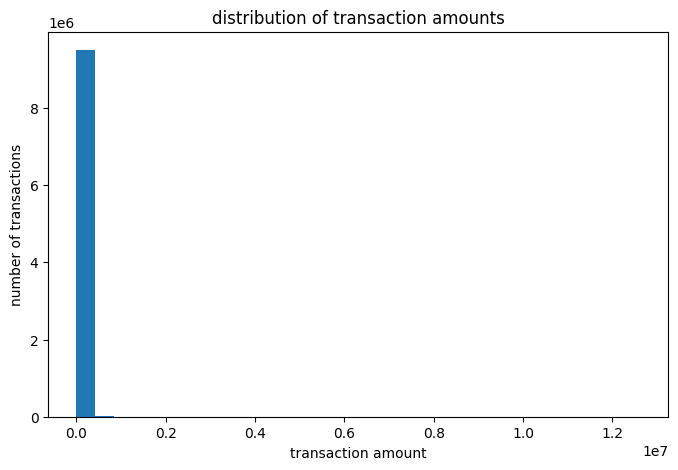

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['Amount'] , bins=30)
plt.xlabel('transaction amount')
plt.ylabel('number of transactions')
plt.title('distribution of transaction amounts')
plt.show()

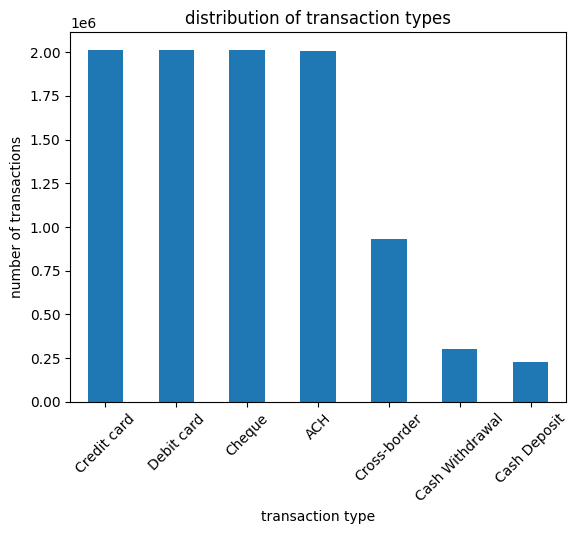

In [29]:
df['Payment_type'].value_counts().plot(kind='bar')
plt.xlabel('transaction type')
plt.ylabel('number of transactions')
plt.title('distribution of transaction types')
plt.xticks(rotation=45)
plt.show()

In [30]:
cleaned_df = df.copy()

In [36]:
cleaned_df.to_csv('AML_Cleaned_Data.csv', index=False)

In [39]:
from google.colab import files
files.download('AML_Cleaned_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>